In [1]:
import seaborn

import pandas as pd
import numpy as np

simmap_file = '../ped-sim/refined_mf.simmap'



In [29]:
%load_ext autoreload
%autoreload 2

# Does this auto load the sex inference analsis imports too? 
from sex_inference_analysis import main, AnalysisParams, do_data_analysis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
size = 30
input_file = f'../ped-sim/outputs/gp-sex/gp-sex-{size}.seg'

output_file = f'results_{size}.csv'

main(input_file=input_file, map_file=simmap_file, output_file=output_file)



                   sample_1                sample_2  chromosome     start  \
0    male-gparent1_g5-b1-i1  male-gparent1_g5-b3-i1           1  11821219   
1    male-gparent1_g5-b1-i1  male-gparent1_g5-b3-i1           1  54833304   
2    male-gparent1_g5-b1-i1  male-gparent1_g5-b3-i1           1  11821219   
3    male-gparent1_g5-b1-i1  male-gparent1_g5-b2-i1           1  23949188   
4    male-gparent1_g5-b1-i1  male-gparent1_g5-b2-i1           1  54833304   
..                      ...                     ...         ...       ...   
144  male-gparent1_g5-b2-i1  male-gparent1_g5-b3-i1          22  27875198   
145  male-gparent1_g5-b2-i1  male-gparent1_g5-b3-i1          22  37259295   
146  male-gparent1_g5-b2-i1  male-gparent1_g5-b3-i1          22  27875198   
147  male-gparent1_g5-b1-i1  male-gparent1_g5-b3-i1          22  37259296   
148  male-gparent1_g5-b1-i1  male-gparent1_g5-b3-i1          22  37259296   

          end  is_co  from_p1  from_p2  ambiguous  
0    11821219   True   

In [30]:
param1 = AnalysisParams(window=500,
               count_ambiguous_co=False,
               remove_dups=False,
               count_p1=True,
               count_p2=True)

final_results = f'final_results_jypter_{size}.csv'
do_data_analysis(input_file=output_file,
                 data_analysis_params_lists=[param1],
                 output_file=final_results,
                 simmap=simmap_file
                 )

In [31]:
results_df = pd.read_csv(final_results, sep='\t')

male_results = results_df[results_df['pedigree_id'].str.contains(r'^male-')]
female_results = results_df[results_df['pedigree_id'].str.contains(r'^female-')]


In [32]:
female_results


,pedigree_id,LOD_0
30,female-gparent1,7.362153
31,female-gparent2,21.393467
32,female-gparent3,8.614087
33,female-gparent4,3.127942
34,female-gparent5,49.722904
35,female-gparent6,33.262177
36,female-gparent7,24.384697
37,female-gparent8,30.703477
38,female-gparent9,24.677135
39,female-gparent10,19.211602


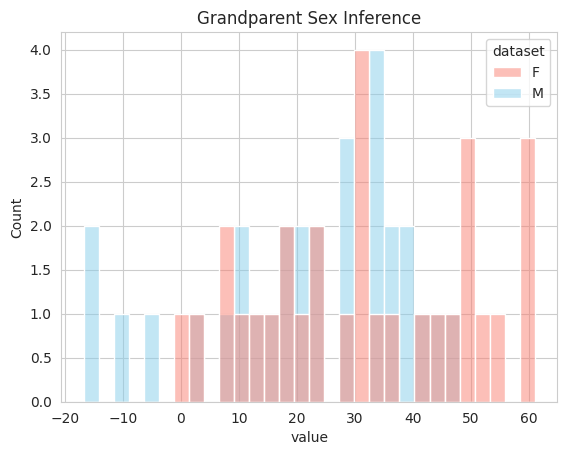

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt

set1 = female_results['LOD_0']
set2 = male_results['LOD_0']


df = pd.DataFrame({
    'value': np.concatenate([set1, set2]),
    'dataset': ['F'] * len(set1) + ['M'] * len(set2)
})

# Plot
sns.histplot(
    data=df, 
    x='value', 
    hue='dataset', 
    palette={'F': 'salmon', 'M': 'skyblue'},
    alpha=0.5,
    bins=30
)

plt.title(f'Grandparent Sex Inference')

plt.show()

